#### Tarea 2
## Notebook Preprocesamiento: Breast Cancer Wisconsin dataset
En la presente tarea se hará uso del dataset **Breast Cancer Wisconsin**, con el objetivo de aplicar dos de los métodos de procesamiento de datos vistos en clase.

El dataset contiene información obtenida a partir de muestras celulares de pacientes con tumores de mama. Cuenta con un total de 699 instancias y 11 atributos, los cuales describen diferentes características de las células analizadas. Los atributos que conforman el dataset son los siguientes: 
| # | Attribute | Values / Description |
|---|---|---|
| 1 | Sample Code Number | ID number |
| 2 | Clump Thickness | 1–10 |
| 3 | Uniformity of Cell Size | 1–10 |
| 4 | Uniformity of Cell Shape | 1–10 |
| 5 | Marginal Adhesion | 1–10 |
| 6 | Single Epithelial Cell Size | 1–10 |
| 7 | Bare Nuclei | 1–10 |
| 8 | Bland Chromatin | 1–10 |
| 9 | Normal Nucleoli | 1–10 |
| 10 | Mitoses | 1–10 |
| 11 | Class | 2 = Benign, 4 = Malignant |

Como se puede observar, la variable objetivo del dataset es **Class**, la cual corresponde a una variable categórica utilizada para clasificar las muestras analizadas. El valor 2 representa los casos benignos, mientras que el valor 4 representa los casos malignos de cáncer de mama.

### Librerias

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Procesamiento del dataset
#### Limpieza 

In [85]:
#El dataset no contiene nombres de columnas, por lo que se agregó manualmente.
column_names = [
    "Sample code number",
    "Clump Thickness",
    "Uniformity of Cell Size",
    "Uniformity of Cell Shape",
    "Marginal Adhesion",
    "Single Epithelial Cell Size",
    "Bare Nuclei",
    "Bland Chromatin",
    "Normal Nucleoli",
    "Mitoses",
    "Class",
] 

df = pd.read_csv(
    "breast-cancer-wisconsin.data",
    names=column_names,
)
describe = df.describe()
describe

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bland Chromatin,Normal Nucleoli,Mitoses,Class
count,6.990000e+02,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000
mean,1.071704e+06,4.417740,3.134478,3.207439,2.806867,3.216023,3.437768,2.866953,1.589413,2.689557
std,6.170957e+05,2.815741,3.051459,2.971913,2.855379,2.214300,2.438364,3.053634,1.715078,0.951273
min,6.163400e+04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,8.706885e+05,2.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,2.000000
50%,1.171710e+06,4.000000,1.000000,1.000000,1.000000,2.000000,3.000000,1.000000,1.000000,2.000000
75%,1.238298e+06,6.000000,5.000000,5.000000,4.000000,4.000000,5.000000,4.000000,1.000000,4.000000
max,1.345435e+07,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


Como se puede observar el atributo *Bare Nuclei* no aparece como numérica, aunque debería contener valores de 1 a 10. Esto ocurre ya que los datos faltantes en este atributo están representados mediante ?, no como NaN, lo que proboca que Pandas interprete toda la columna como texto. En la siguiente gráfica se puede apreciar la cantidad de datos faltantes.

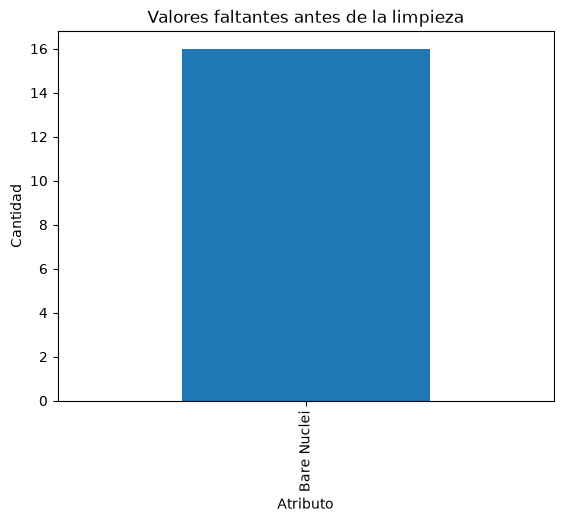

In [86]:
valores_faltantes = (df == '?').sum()

valores_faltantes[valores_faltantes > 0].plot(kind='bar')

plt.title('Valores faltantes antes de la limpieza')
plt.ylabel('Cantidad')
plt.xlabel('Atributo')
plt.show()

Lo que se puede hacer es convertir los valores faltantes ? a Nan y de ahi convertir la variable a númerica

In [37]:
bare_antes = pd.to_numeric(df['Bare Nuclei'].replace('?', np.nan)).copy() #guardamos la columna antes de imputar
df.replace('?', np.nan, inplace=True)
df.isnull().sum() #comprobamos que los valores faltantes se han reemplazado por NaN

Sample code number              0
Clump Thickness                 0
Uniformity of Cell Size         0
Uniformity of Cell Shape        0
Marginal Adhesion               0
Single Epithelial Cell Size     0
Bare Nuclei                    16
Bland Chromatin                 0
Normal Nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64

In [38]:
df['Bare Nuclei'] = pd.to_numeric(df['Bare Nuclei']) #convertimos la columna 'Bare Nuclei' a tipo numérico
describe = df.describe()
describe

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
count,6.990000e+02,699.000000,699.000000,699.000000,699.000000,699.000000,683.000000,699.000000,699.000000,699.000000,699.000000
mean,1.071704e+06,4.417740,3.134478,3.207439,2.806867,3.216023,3.544656,3.437768,2.866953,1.589413,2.689557
std,6.170957e+05,2.815741,3.051459,2.971913,2.855379,2.214300,3.643857,2.438364,3.053634,1.715078,0.951273
min,6.163400e+04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,8.706885e+05,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000
50%,1.171710e+06,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,2.000000
75%,1.238298e+06,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000,4.000000
max,1.345435e+07,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


De aqui, ahora si toca decidir qué hacer con los valores faltantes. En este caso decidí remplazar los valores faltantes del atributo Bare Nuclei utilizando la mediana de los valores disponibles. Esta medida se eligió debido a que es menos sensible a valores extremos que la media y permite conservar los registros que presentan datos faltantes, evitando eliminar información de los demás atributos. 

In [39]:
mediana = df['Bare Nuclei'].median() #calcular la mediana de la columna 'Bare Nuclei'
print("Mediana:", mediana)
df['Bare Nuclei'] = df['Bare Nuclei'].fillna(mediana) #reemplazamos los valores faltantes con la mediana
df.isnull().sum() #comprobamos que los valores faltantes se han reemplazado

Mediana: 1.0


Sample code number             0
Clump Thickness                0
Uniformity of Cell Size        0
Uniformity of Cell Shape       0
Marginal Adhesion              0
Single Epithelial Cell Size    0
Bare Nuclei                    0
Bland Chromatin                0
Normal Nucleoli                0
Mitoses                        0
Class                          0
dtype: int64

Para hacer la representación gráfica de los datos, podemos utilizar un histograma para visualizar la distribución de la columna *Bare Nuclei* antes y después de reemplazar los valores faltantes con la mediana.

Datos antes: 683
Valores faltantes antes: 16

Datos después: 699
Valores faltantes después: 0


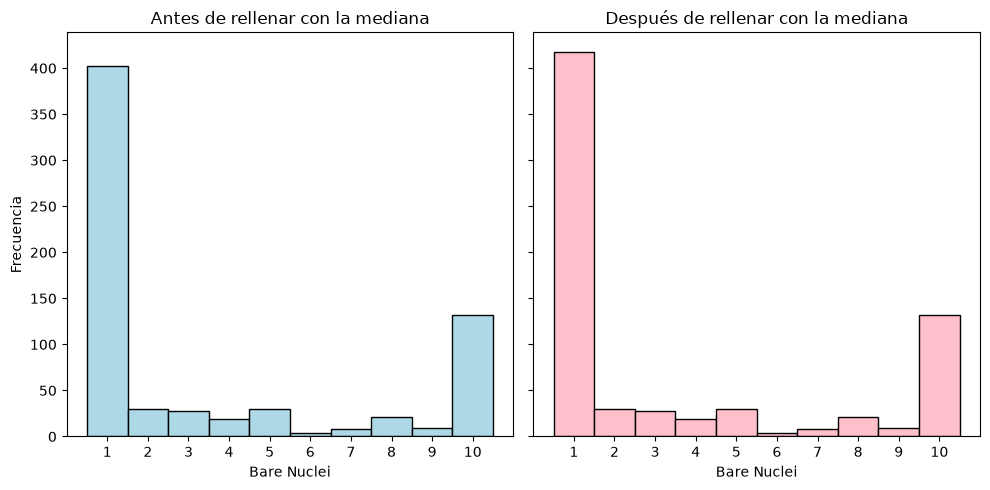

In [56]:
print("Datos antes:", bare_antes.count())
print("Valores faltantes antes:", bare_antes.isna().sum())

print("\nDatos después:", df['Bare Nuclei'].count())
print("Valores faltantes después:", df['Bare Nuclei'].isna().sum())
bins = np.arange(0.5, 11.5, 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

axes[0].hist(bare_antes.dropna(), bins=bins, color='lightblue', edgecolor='black')
axes[0].set_title('Antes de rellenar con la mediana')
axes[0].set_xlabel('Bare Nuclei')
axes[0].set_ylabel('Frecuencia')
axes[0].set_xticks(range(1, 11))

axes[1].hist(df['Bare Nuclei'], bins=bins, color='pink', edgecolor='black')
axes[1].set_title('Después de rellenar con la mediana')
axes[1].set_xlabel('Bare Nuclei')
axes[1].set_xticks(range(1, 11))

plt.tight_layout()
plt.show()

El uso de la mediana permitió completar los 16 valores faltantes sin tener que eliminar las instancias correspondientes y perder la información de los demás atributos. Debido a que estos valores representan una proporción pequeña del total de datos, el rellenado con la mediana no produjo un cambio considerable en la distribución de Bare Nuclei, pero sí permitió conservar las 699 instancias originales para los análisis posteriores.

#### Reducción de dimensionalidad con PCA

Para realizar la reducción de dimensionalidad mediante PCA, primero se separó la variable objetivo **Class** de los dema[as atributos]. Asimismo, se eliminó **Sample Code Number**, debido a que corresponde únicamente a un identificador y no proporciona información relevante. 

In [ ]:
# se excluyen el identificador y la variable objetivo
X = df.drop(columns=['Sample code number', 'Class'])

# Variable objetivo separada
Y = df['Class']

print("Dimensiones de X:", X.shape)

Dimensiones de X: (699, 9)
Dimensiones de Y: (699,)


Antes de aplicar PCA, decidí hacer una estandarización de los datos. A pesar de que las 9 características utilizan la misma escala de 1 a 10, sigue siendo conveniente estandarizarlas porque no necesariamente presentan la misma media ni variabilidad. 

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
print("Media:", X_scaled.mean(axis=0).round(2))
print("Desviación estándar:", X_scaled.std(axis=0).round(2))

Media: [-0. -0. -0.  0.  0. -0.  0. -0. -0.]
Desviación estándar: [1. 1. 1. 1. 1. 1. 1. 1. 1.]


El procedimeinto hace que la media sea cercana a 0 y que tenga una desviación estándar de 1, evitando que las diferencias en la variabilidad de los atributos tengan una influencia desproporcionada sobre los componentes principales. Una vez terminado este paso, se puede realizar el PCA. 

In [ ]:
from sklearn.decomposition import PCA

pca = PCA()

X_pca = pca.fit_transform(X_scaled)
varianza = pca.explained_variance_ratio_

for i, valor in enumerate(varianza):
    print(f"PC{i+1}: {valor:.4f} ({valor*100:.2f}%)")

PC1: 0.6545 (65.45%)
PC2: 0.0861 (8.61%)
PC3: 0.0599 (5.99%)
PC4: 0.0517 (5.17%)
PC5: 0.0423 (4.23%)
PC6: 0.0337 (3.37%)
PC7: 0.0329 (3.29%)
PC8: 0.0291 (2.91%)
PC9: 0.0099 (0.99%)


Al aplicar PCA se obtuvienen 9 componentes principales que corresponden al número de atributos originales. Estos componentes principales están ordenados de acuerdo con la cantidad de varianza que explican, por lo que PC1 concentra la mayor proporción de información, seguido de PC2, PC3 y así sucesivamente. A medida que se agregan más, la cantidad de información adicional que aportan disminuye. En base a la varianza acumulada se puede determinar cuántos de estos es conveniente conservar.

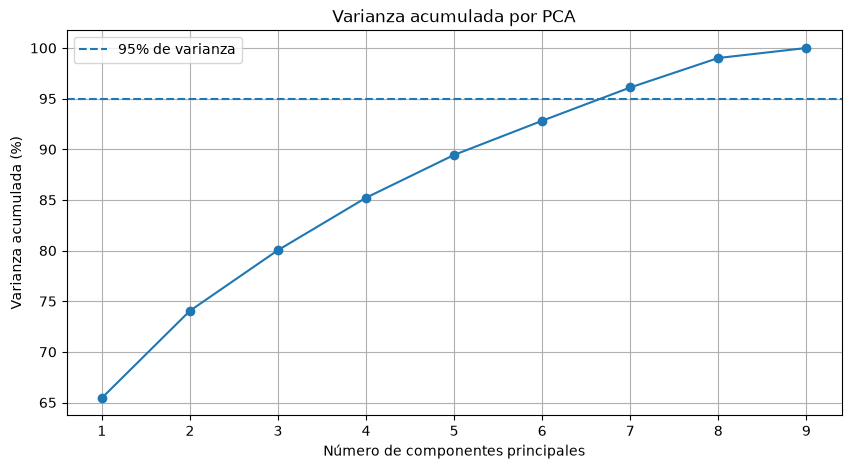

In [87]:
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_) #Varianza acomulada
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(varianza_acumulada) + 1),
    varianza_acumulada * 100,
    marker='o'
)

plt.axhline(
    y=95,
    linestyle='--',
    label='95% de varianza'
)

plt.xlabel('Número de componentes principales')
plt.ylabel('Varianza acumulada (%)')
plt.title('Varianza acumulada por PCA')

plt.xticks(range(1, 10))
plt.legend()
plt.grid()

plt.show()

La gráfica de **varianza acumulada** permite observar cuánta información del dataset se conserva a medida que se agregan componentes principales. Para este análisis se estableció como criterio conservar al menos el 95 % de la varianza total, donde hay un buen equilibrio entre reducción de caracteristicas y conservacion de la varianza.

In [60]:
n_componentes = np.argmax(
    varianza_acumulada >= 0.95
) + 1

print(
    "Componentes necesarios para conservar "
    "al menos el 95% de la varianza:",
    n_componentes
)

Componentes necesarios para conservar al menos el 95% de la varianza: 7


Se determinó que 7 es el número mínimo de componentes principales necesarios para conservar al menos el 95 % de la varianza total del dataset. De esta manera, la selección de los componentes no se realiza de forma arbitraria, sino con base en la proporción de varianza que son capaces de representar. Para profundizar en el análisis de los componentes seleccionados, se realizarán gráficas de dispersión comparando PC1. 

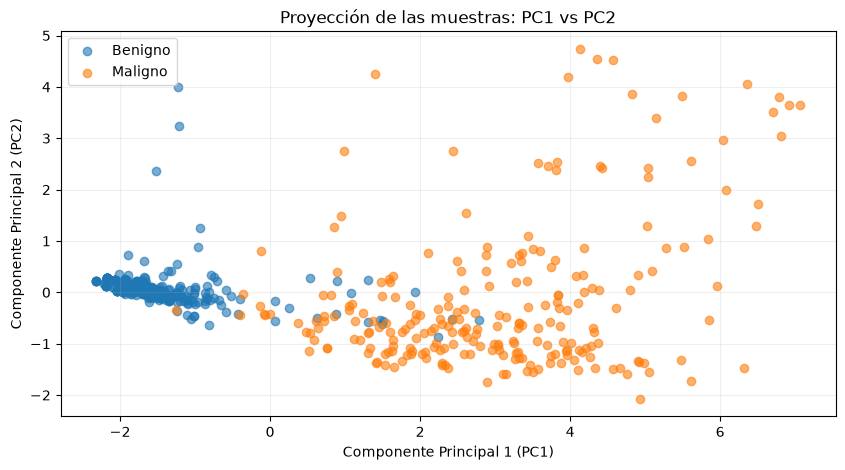

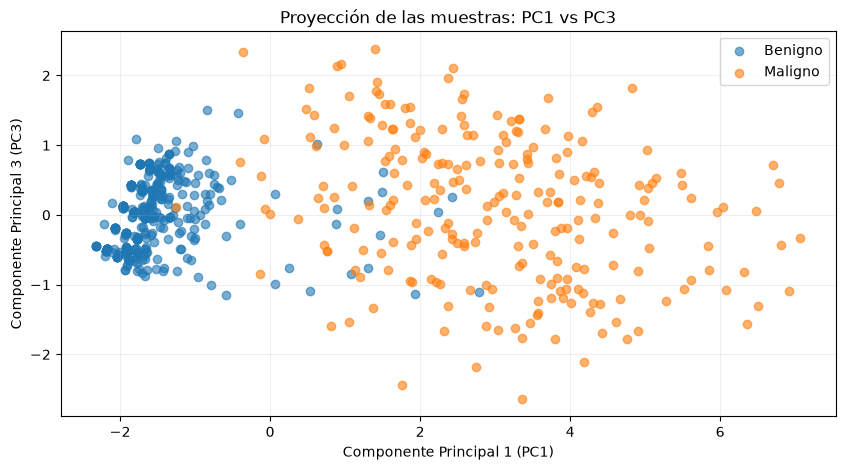

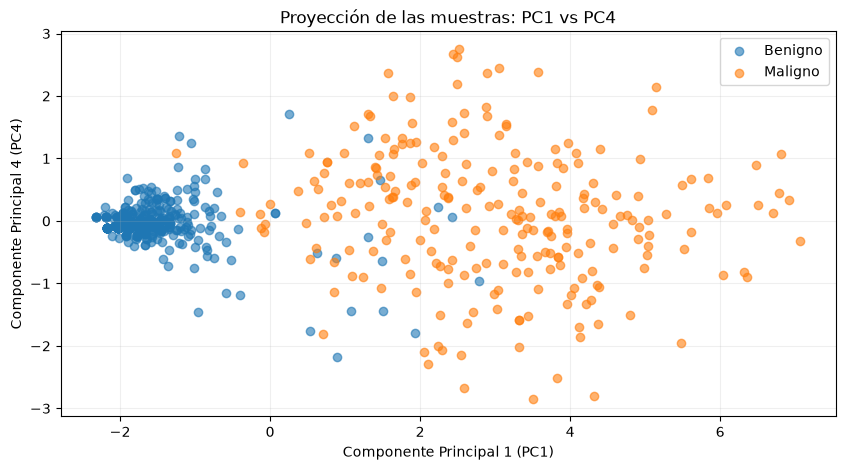

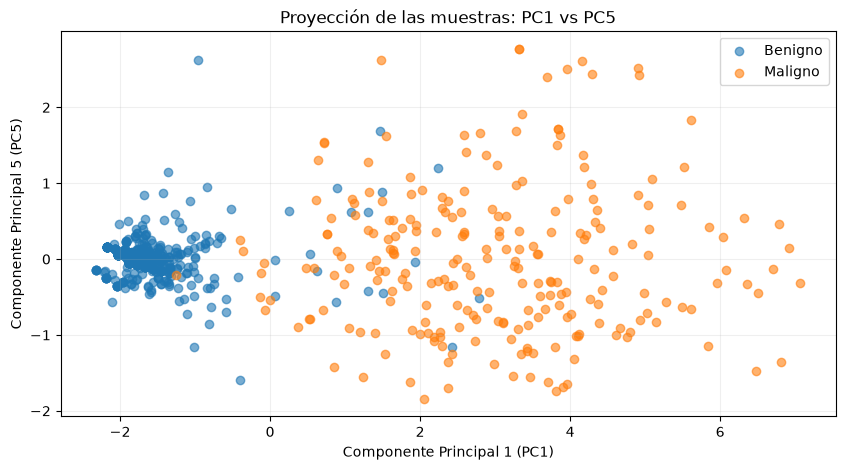

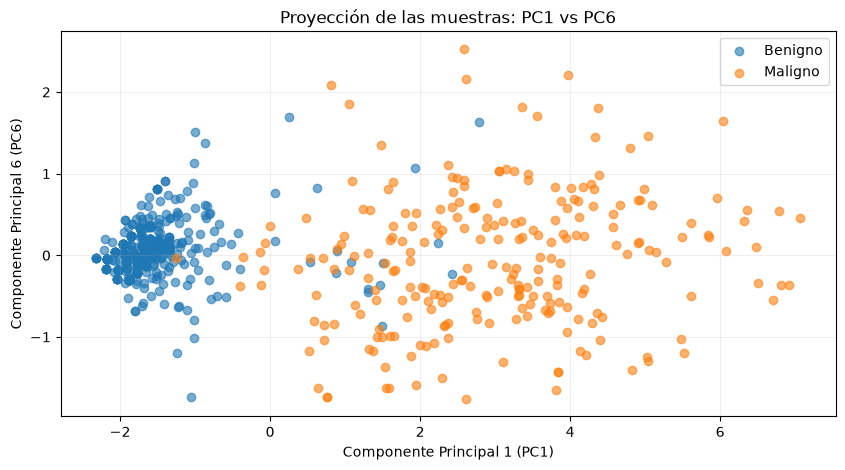

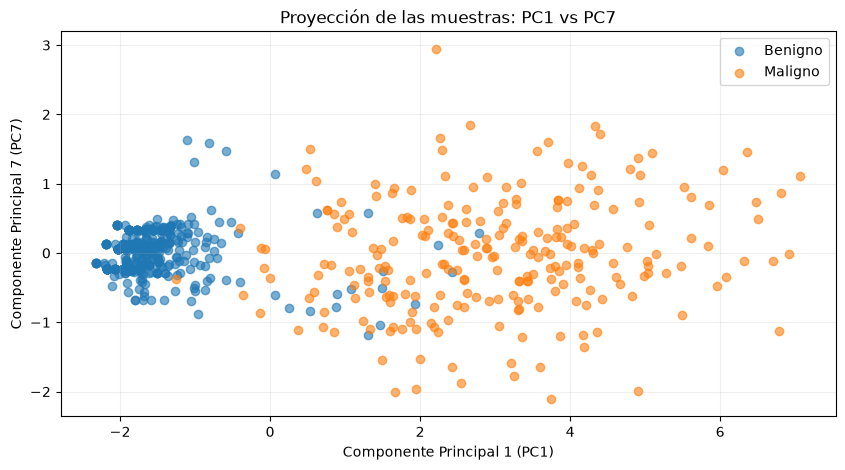

In [70]:
# Comparar PC1 con cada uno de los demás componentes seleccionados

for i in range(1, n_componentes):
    plt.figure(figsize=(10, 5))

    for clase, nombre in [(2, 'Benigno'), (4, 'Maligno')]:
        plt.scatter(
            X_pca_final[Y == clase, 0],
            X_pca_final[Y == clase, i],
            label=nombre,
            alpha=0.6
        )

    plt.xlabel('Componente Principal 1 (PC1)')
    plt.ylabel(f'Componente Principal {i+1} (PC{i+1})')
    plt.title(f'Proyección de las muestras: PC1 vs PC{i+1}')
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

Se comparó el primer componente principal (PC1) con cada uno de los demás componentes seleccionados. Se utilizó PC1 como eje común debido a que concentra la mayor proporción de varianza del dataset. Las muestras fueron diferenciadas de acuerdo con su clasificación como benignas (azules) o malignas (naranjas).

Se puede observar un patrón consistente en la distribución de las muestras. Los casos benignos se concentran principalmente en valores negativos de PC1, mientras que los casos malignos presentan, en su mayoría, valores positivos. Esta tendencia se mantiene independientemente del componente utilizado en el segundo eje, lo que indica que PC1 concentra una parte importante de la variabilidad. Por otro lado, de  PC2 a PC7 se modifican principalmente la dispersión de las muestras en el eje vertical, sin mostrar una separación entre clases tan marcada como la observada a lo largo de PC1.

Ahora bien, vale la pena revisar las caracteristicas originales que contribuyen a componente original. 

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(pca.components_))],
    index=X.columns
)

display(loadings[['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9']])

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
Clump Thickness,0.302805,-0.146029,0.862217,0.088217,-0.071928,0.269469,-0.001313,-0.240817,0.001407
Uniformity of Cell Size,0.381190,-0.049564,-0.019092,-0.202639,0.137357,0.100098,0.215213,0.440887,0.735681
Uniformity of Cell Shape,0.377574,-0.085270,0.034584,-0.175155,0.104691,0.032002,0.142044,0.586010,-0.665375
Marginal Adhesion,0.332823,-0.044719,-0.421448,0.470317,-0.034628,0.680834,-0.086104,-0.118670,-0.046718
Single Epithelial Cell Size,0.336391,0.164038,-0.110104,-0.373329,0.682582,-0.035598,-0.183377,-0.450572,-0.067869
Bare Nuclei,0.333497,-0.247710,0.003671,0.543177,0.127506,-0.574866,-0.411875,0.102999,0.073394
Bland Chromatin,0.345956,-0.229942,-0.197449,0.006990,-0.255191,-0.314597,0.673015,-0.409760,-0.058811
Normal Nucleoli,0.335840,0.025027,-0.131650,-0.455372,-0.631803,-0.038416,-0.504063,-0.082475,0.018898
Mitoses,0.229818,0.908394,0.094593,0.239686,-0.131627,-0.143607,0.125674,0.042510,-0.007529


El análisis de los loadings permite identificar qué características originales tienen mayor influencia sobre cada componente principal. Se observa que algunos componentes están fuertemente relacionados con algun atributo en  específico , como PC2 con Mitoses (0.908), PC3 con Clump Thickness (0.862) y PC7 con Bland Chromatin (0.673). En contraste, PC1 no está dominado por una sola característica, sino que presenta contribuciones relativamente similares de la mayoría de los atributos. Esto indica que PC1 representa un patrón general que combina distintas características celulares, lo cual ayuda a explicar por qué en las gráficas anteriores este componente muestra una separación visible entre gran parte de las muestras benignas y malignas.

### Conclusión

En la tarea se realizaron dos tipos de preprocesamiento del dataset **Breast Cancer Wisconsin**: limpieza de datos y reducción de dimensionalidad mediante PCA. Durante la limpieza se identificaron 16 valores faltantes en el atributo Bare Nuclei, los cuales fueron tratados mediante la mediana. Esto permitió conservar las 699 instancias originales sin modificar considerablemente la distribución de los datos.

Posteriormente, mediante PCA se logró reducir las 9 características originales a 7 componentes principales, conservando al menos el 95 % de la varianza presente en los datos. El análisis también permitió observar que PC1 concentra información proveniente de varias características celulares y que, al representarlo junto con los demás componentes, se observa una separación considerable entre gran parte de las muestras benignas y malignas. 

Al combinar ambas técnicas se obtuvo un dataset más limpio y una representación de menor dimensionalidad, conservando la mayor parte de la información disponible para posibles análisis o modelos.

### Referencias
Wolberg, W. H. (1992). Breast Cancer Wisconsin (Original) [Data set]. University of Wisconsin Hospitals, Madison
